In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, load_breast_cancer, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
wine = load_wine()

X = wine.data
y = wine.target

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [8]:
print("Wine Dataset")
print("Original Features:", X.shape[1])
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Variance:", sum(pca.explained_variance_ratio_))

Wine Dataset
Original Features: 13
Explained Variance Ratio: [0.36198848 0.1920749 ]
Cumulative Variance: 0.5540633835693529


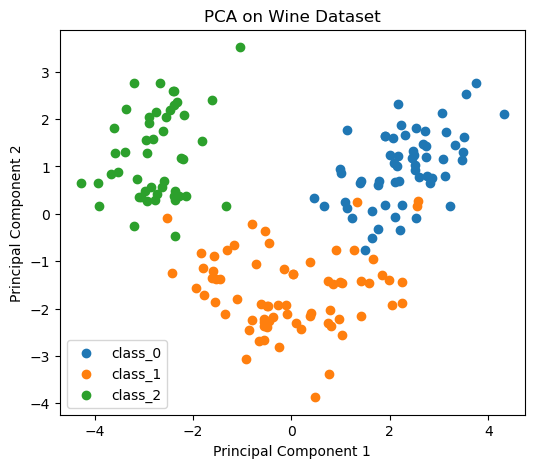

In [9]:
plt.figure(figsize=(6,5))

for i in range(3):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=wine.target_names[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Wine Dataset")
plt.legend()
plt.show()

In [10]:
breast = load_breast_cancer()

X = breast.data
y = breast.target

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [13]:
print("Original Features:",X.shape[1])
print("Explained Variance:",pca.explained_variance_ratio_)
print("Cumulative:",sum(pca.explained_variance_ratio_))

Original Features: 30
Explained Variance: [0.44272026 0.18971182]
Cumulative: 0.6324320765155944


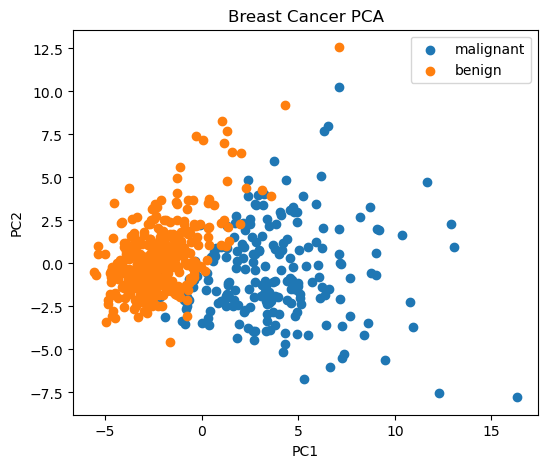

In [14]:
plt.figure(figsize=(6,5))

for i in range(2):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=breast.target_names[i]
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Breast Cancer PCA")
plt.legend()

plt.show()

In [15]:
digits = load_digits()

X = digits.data
y = digits.target

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [18]:
print("Original Features:",X.shape[1])
print("Explained Variance:",pca.explained_variance_ratio_)
print("Cumulative:",sum(pca.explained_variance_ratio_))

Original Features: 64
Explained Variance: [0.12033916 0.09561054]
Cumulative: 0.21594970500832789


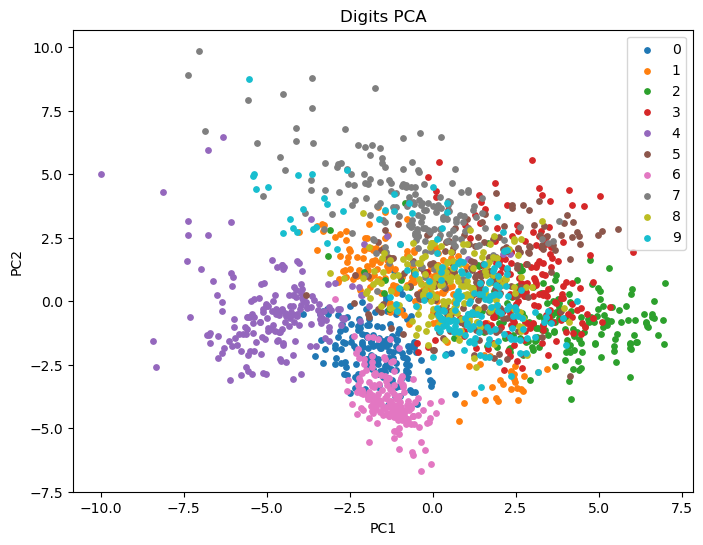

In [19]:
plt.figure(figsize=(8,6))

for i in range(10):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=str(i),
        s=15
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits PCA")
plt.legend()

plt.show()

In [26]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [29]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cumulative_variance)

[0.12033916 0.21594971 0.30039385 0.36537793 0.41397948 0.45612068
 0.49554151 0.52943532 0.55941753 0.58873755 0.61655561 0.64232616
 0.66507919 0.68735099 0.70900328 0.72814495 0.74590042 0.76228111
 0.77824572 0.79313763 0.80661732 0.81933664 0.83099501 0.84157148
 0.85132464 0.86077023 0.86940036 0.87776679 0.88574372 0.89320844
 0.90046426 0.90738337 0.91392246 0.92033038 0.92624422 0.93195585
 0.93719222 0.94201029 0.94654748 0.95077911 0.95483964 0.95881049
 0.96237542 0.9657833  0.96906165 0.97217197 0.97505772 0.97782262
 0.98041436 0.98275919 0.98494176 0.98697774 0.98893286 0.99076605
 0.99244551 0.99405787 0.9955355  0.99688668 0.99813769 0.99917465
 1.         1.         1.         1.        ]


In [30]:
components = np.argmax(cumulative_variance >= 0.90) + 1

print("Minimum number of components required:", components)

Minimum number of components required: 31


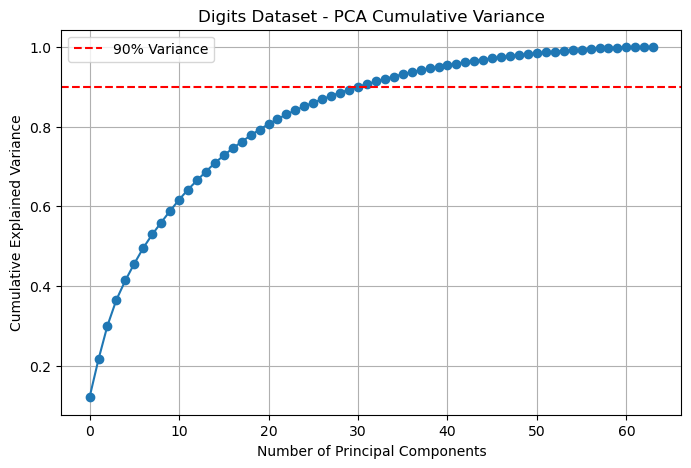

In [31]:
plt.figure(figsize=(8,5))

plt.plot(cumulative_variance, marker='o')

plt.axhline(y=0.90, color='red', linestyle='--', label='90% Variance')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Digits Dataset - PCA Cumulative Variance")

plt.legend()

plt.grid(True)

plt.show()